In [4]:
import pandas as pd

In [6]:
def preparar_csv_para_modelo(input_csv, output_csv=None, meu_ip=None, remover_src_ip=True):
    import pandas as pd

    # mapeamento: nome do treino -> nome no CSV capturado
    column_mapping = {
        'Flow Duration': 'flow_duration',
        'Total Fwd Packets': 'tot_fwd_pkts',
        'Total Backward Packets': 'tot_bwd_pkts',
        'Total Length of Fwd Packets': 'totlen_fwd_pkts',
        'Total Length of Bwd Packets': 'totlen_bwd_pkts',
        'Fwd Packet Length Max': 'fwd_pkt_len_max',
        'Fwd Packet Length Min': 'fwd_pkt_len_min',
        'Fwd Packet Length Mean': 'fwd_pkt_len_mean',
        'Fwd Packet Length Std': 'fwd_pkt_len_std',
        'Bwd Packet Length Max': 'bwd_pkt_len_max',
        'Bwd Packet Length Min': 'bwd_pkt_len_min',
        'Bwd Packet Length Mean': 'bwd_pkt_len_mean',
        'Bwd Packet Length Std': 'bwd_pkt_len_std',
        'Flow Bytes/s': 'flow_byts_s',
        'Flow Packets/s': 'flow_pkts_s',
        'Flow IAT Mean': 'flow_iat_mean',
        'Flow IAT Std': 'flow_iat_std',
        'Flow IAT Max': 'flow_iat_max',
        'Flow IAT Min': 'flow_iat_min',
        'Fwd IAT Total': 'fwd_iat_tot',
        'Fwd IAT Mean': 'fwd_iat_mean',
        'Fwd IAT Std': 'fwd_iat_std',
        'Fwd IAT Max': 'fwd_iat_max',
        'Fwd IAT Min': 'fwd_iat_min',
        'Bwd IAT Total': 'bwd_iat_tot',
        'Bwd IAT Mean': 'bwd_iat_mean',
        'Bwd IAT Std': 'bwd_iat_std',
        'Bwd IAT Max': 'bwd_iat_max',
        'Bwd IAT Min': 'bwd_iat_min',
        'Fwd PSH Flags': 'fwd_psh_flags',
        'Fwd URG Flags': 'fwd_urg_flags',
        'Fwd Header Length': 'fwd_header_len',
        'Bwd Header Length': 'bwd_header_len',
        'Fwd Packets/s': 'fwd_pkts_s',
        'Bwd Packets/s': 'bwd_pkts_s',
        'Min Packet Length': 'pkt_len_min',
        'Max Packet Length': 'pkt_len_max',
        'Packet Length Mean': 'pkt_len_mean',
        'Packet Length Std': 'pkt_len_std',
        'Packet Length Variance': 'pkt_len_var',
        'FIN Flag Count': 'fin_flag_cnt',
        'SYN Flag Count': 'syn_flag_cnt',
        'RST Flag Count': 'rst_flag_cnt',
        'PSH Flag Count': 'psh_flag_cnt',
        'ACK Flag Count': 'ack_flag_cnt',
        'URG Flag Count': 'urg_flag_cnt',
        'CWE Flag Count': 'cwr_flag_count',
        'ECE Flag Count': 'ece_flag_cnt',
        'Down/Up Ratio': 'down_up_ratio',
        'Average Packet Size': 'pkt_size_avg',
        'Avg Fwd Segment Size': 'fwd_seg_size_avg',
        'Avg Bwd Segment Size': 'bwd_seg_size_avg',
        'Subflow Fwd Packets': 'subflow_fwd_pkts',
        'Subflow Fwd Bytes': 'subflow_fwd_byts',
        'Subflow Bwd Packets': 'subflow_bwd_pkts',
        'Subflow Bwd Bytes': 'subflow_bwd_byts',
        'Init_Win_bytes_forward': 'init_fwd_win_byts',
        'Init_Win_bytes_backward': 'init_bwd_win_byts',
        'act_data_pkt_fwd': 'fwd_act_data_pkts',
        'min_seg_size_forward': 'fwd_seg_size_min',
        'Active Mean': 'active_mean',
        'Active Std': 'active_std',
        'Active Max': 'active_max',
        'Active Min': 'active_min',
        'Idle Mean': 'idle_mean',
        'Idle Std': 'idle_std',
        'Idle Max': 'idle_max',
        'Idle Min': 'idle_min',
    }

    training_columns = list(column_mapping.keys())
    rename_dict = {captured_name: train_name for train_name, captured_name in column_mapping.items()}

    df = pd.read_csv(input_csv)

    total_antes = len(df)
    removidas_por_src_ip = 0

    if remover_src_ip and meu_ip is not None:
        if 'src_ip' not in df.columns:
            raise ValueError("A coluna 'src_ip' não foi encontrada no CSV capturado.")

        mascara_remocao = df['src_ip'].astype(str).str.strip() == str(meu_ip).strip()
        removidas_por_src_ip = int(mascara_remocao.sum())
        df = df[~mascara_remocao].copy()

    df = df.rename(columns=rename_dict)

    missing_columns = [col for col in training_columns if col not in df.columns]
    if missing_columns:
        raise ValueError(
            f"As seguintes colunas do treino não foram encontradas no CSV capturado: {missing_columns}"
        )

    df_final = df[training_columns].copy()

    total_depois = len(df_final)

    print(f"Total de instâncias antes do filtro: {total_antes}")
    print(f"Instâncias removidas por src_ip == {meu_ip}: {removidas_por_src_ip}")
    print(f"Total de instâncias após o filtro: {total_depois}")

    if output_csv is not None:
        df_final.to_csv(output_csv, index=False)
        print(f"CSV salvo em: {output_csv}")

    return df_final

In [8]:
preparar_csv_para_modelo(input_csv='data/raw/captures/flows_20260415_163448.csv', output_csv='data/processed/prepared_flows.csv', meu_ip='10.5.17.38', remover_src_ip=True)

Total de instâncias antes do filtro: 31135
Instâncias removidas por src_ip == 10.5.17.38: 10
Total de instâncias após o filtro: 31125
CSV salvo em: data/processed/prepared_flows.csv


,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,25.702085,11,0,1100,0,100,100,100.00,0.000000,0,...,11,20,0,0,0,0,0,0,0,0
1,42.392740,25,0,5632,0,604,87,225.28,213.410313,0,...,25,20,0,0,0,0,0,0,0,0
2,57.548532,18,0,3870,0,215,215,215.00,0.000000,0,...,18,20,0,0,0,0,0,0,0,0
4,0.436694,5,0,325,0,65,65,65.00,0.000000,0,...,5,20,0,0,0,0,0,0,0,0
5,51.405335,16,0,3440,0,215,215,215.00,0.000000,0,...,16,20,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31130,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0
31131,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0
31132,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0
31133,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0


In [9]:
df = pd.read_csv("data/processed/prepared_flows.csv")
df.head()

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,25.702085,11,0,1100,0,100,100,100.00,0.000000,0,...,11,20,0,0,0,0,0,0,0,0
1,42.392740,25,0,5632,0,604,87,225.28,213.410313,0,...,25,20,0,0,0,0,0,0,0,0
2,57.548532,18,0,3870,0,215,215,215.00,0.000000,0,...,18,20,0,0,0,0,0,0,0,0
3,0.436694,5,0,325,0,65,65,65.00,0.000000,0,...,5,20,0,0,0,0,0,0,0,0
4,51.405335,16,0,3440,0,215,215,215.00,0.000000,0,...,16,20,0,0,0,0,0,0,0,0


In [10]:
import joblib

# Carrega dados para predição
df_pred = pd.read_csv("data/processed/prepared_flows.csv")
X_pred = df_pred[features_order] if "features_order" in globals() else df_pred

# Carrega modelo e LabelEncoder
modelo = joblib.load("modelo/random_forest_model.joblib")
label_encoder = joblib.load("modelo/label_encoder.joblib")



In [11]:
# Predição
pred_encoded = modelo.predict(X_pred)

# Converte para rótulos originais (quando aplicável)
try:
    pred_labels = label_encoder.inverse_transform(pred_encoded.astype(int))
except Exception:
    pred_labels = pred_encoded

# Resultado
resultado = df_pred.copy()
resultado["predicao_codificada"] = pred_encoded
resultado["predicao_rotulo"] = pred_labels

resultado[["predicao_codificada", "predicao_rotulo"]].head(20)

,predicao_codificada,predicao_rotulo
0,0,Benign
1,0,Benign
2,0,Benign
3,0,Benign
4,0,Benign
5,0,Benign
6,0,Benign
7,0,Benign
8,0,Benign
9,0,Benign


In [13]:
resultado['predicao_rotulo'].value_counts()

predicao_rotulo
Benign    31125
Name: count, dtype: int64

In [14]:
resultado

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,predicao_codificada,predicao_rotulo
0,25.702085,11,0,1100,0,100,100,100.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign
1,42.392740,25,0,5632,0,604,87,225.28,213.410313,0,...,0,0,0,0,0,0,0,0,0,Benign
2,57.548532,18,0,3870,0,215,215,215.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign
3,0.436694,5,0,325,0,65,65,65.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign
4,51.405335,16,0,3440,0,215,215,215.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31120,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign
31121,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign
31122,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign
31123,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,0,0,0,0,0,0,0,0,0,Benign


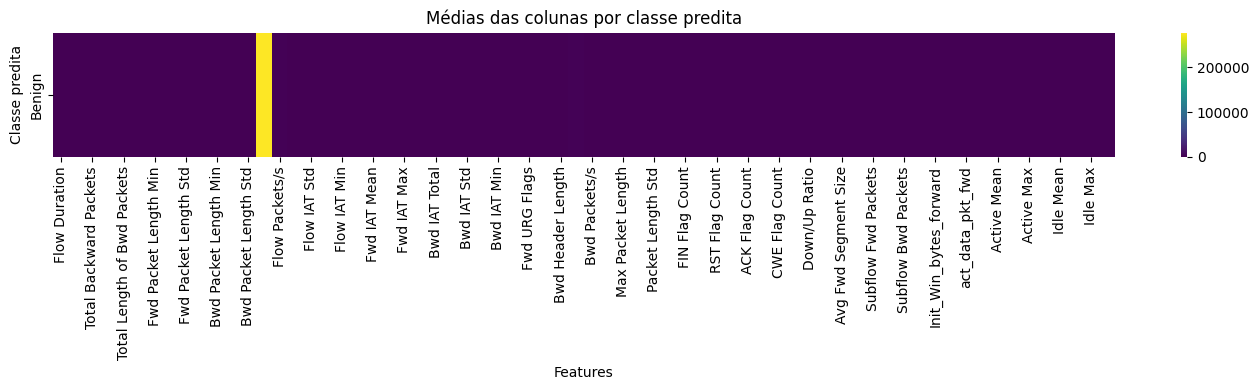

<Figure size 1800x600 with 0 Axes>

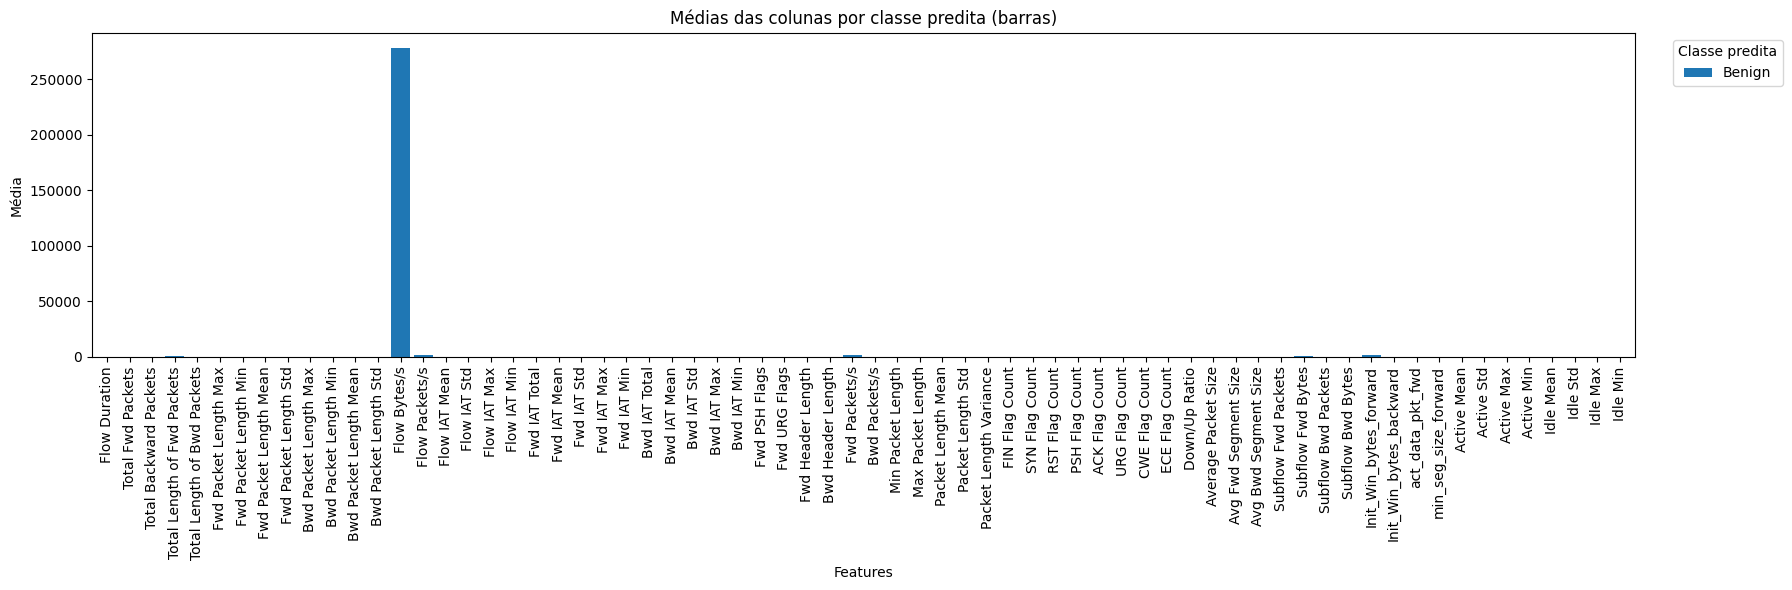

In [16]:
import seaborn as sns

import matplotlib.pyplot as plt

# Médias das colunas numéricas por classe predita
medias_por_classe = (
    resultado
    .drop(columns=["predicao_codificada"], errors="ignore")
    .groupby("predicao_rotulo")
    .mean(numeric_only=True)
)

# Heatmap das médias
plt.figure(figsize=(14, max(4, medias_por_classe.shape[0] * 1.2)))
sns.heatmap(medias_por_classe, cmap="viridis", annot=False)
plt.title("Médias das colunas por classe predita")
plt.xlabel("Features")
plt.ylabel("Classe predita")
plt.tight_layout()
# Gráfico de barras das médias por classe (cada barra = uma feature)
plt.figure(figsize=(18, 6))
medias_por_classe.T.plot(kind="bar", figsize=(18, 6), width=0.85)
plt.title("Médias das colunas por classe predita (barras)")
plt.xlabel("Features")
plt.ylabel("Média")
plt.legend(title="Classe predita", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

Total de colunas numéricas: 68


,count,mean,std,min,25%,50%,75%,max
Flow Duration,31125.0,0.020538,0.893117,0.0,0.0,0.0,0.0,57.548532
Total Fwd Packets,31125.0,2.007711,0.277234,2.0,2.0,2.0,2.0,25.000000
Total Backward Packets,31125.0,0.000996,0.031544,0.0,0.0,0.0,0.0,1.000000
Total Length of Fwd Packets,31125.0,122.262618,121.718234,120.0,120.0,120.0,120.0,16280.000000
Total Length of Bwd Packets,31125.0,0.058924,1.876949,0.0,0.0,0.0,0.0,94.000000
...,...,...,...,...,...,...,...,...
Active Min,31125.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
Idle Mean,31125.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
Idle Std,31125.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000
Idle Max,31125.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.000000


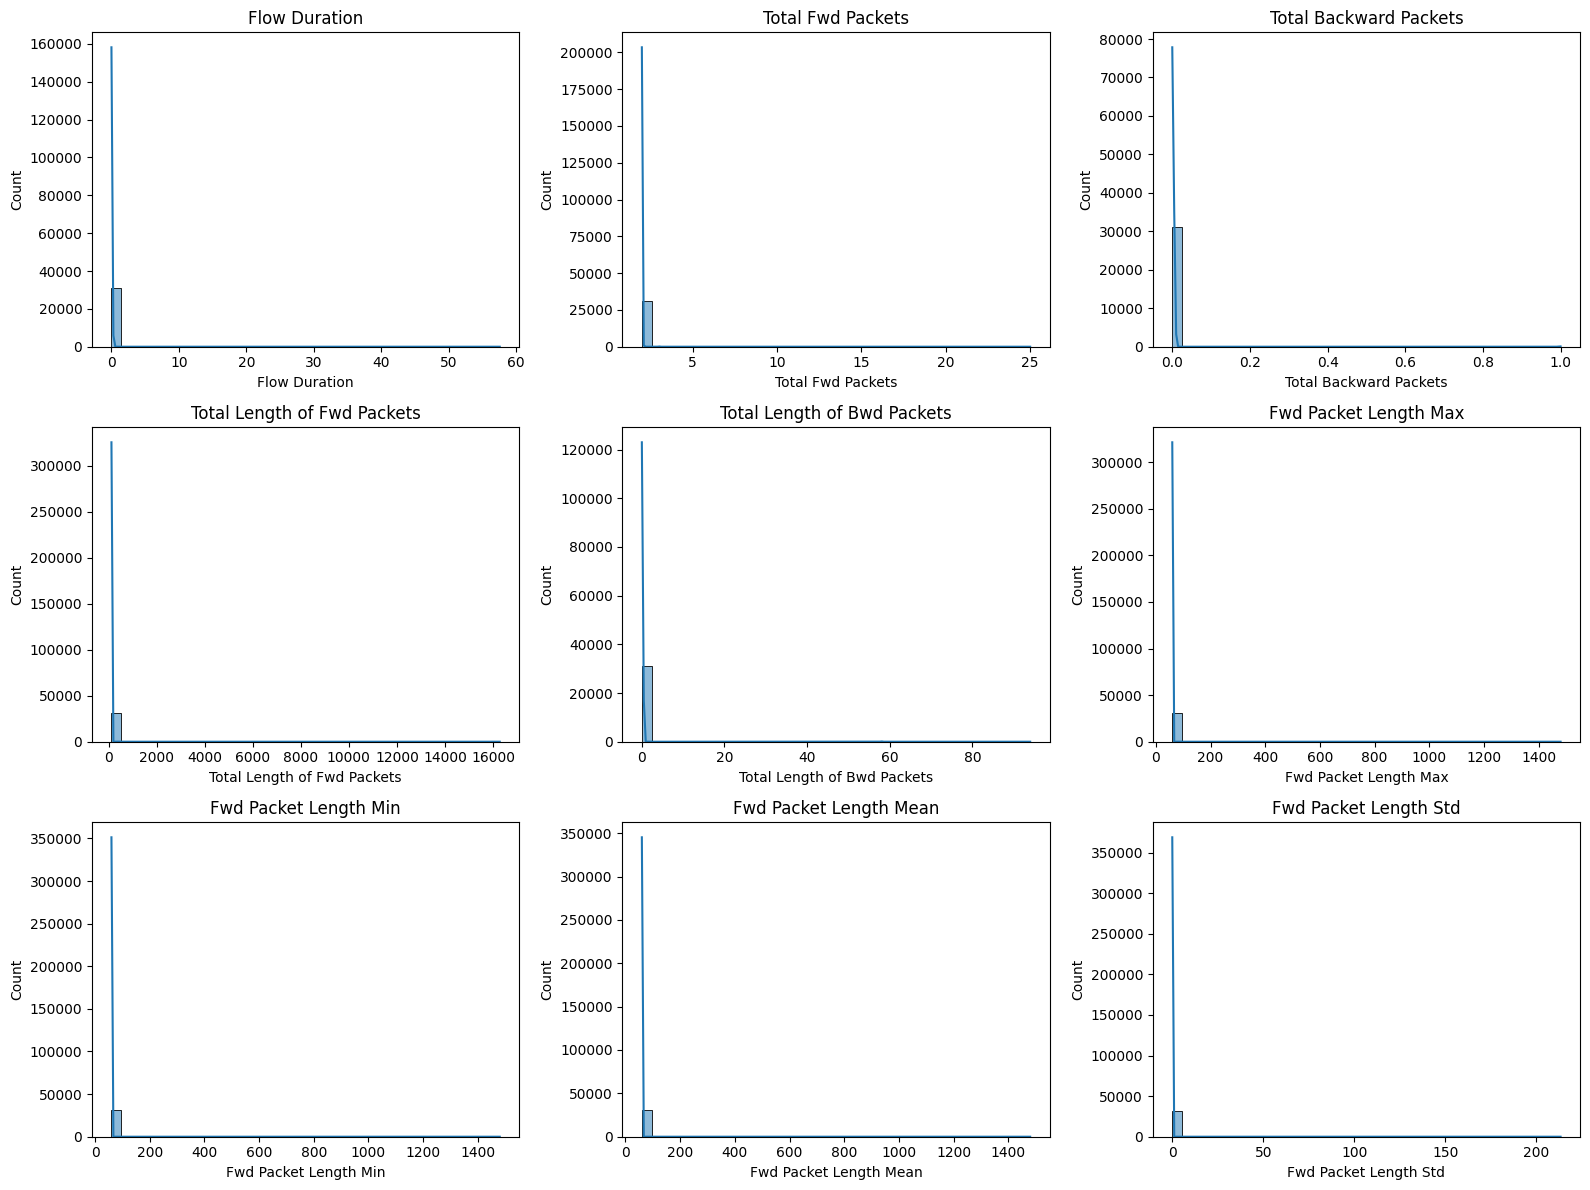

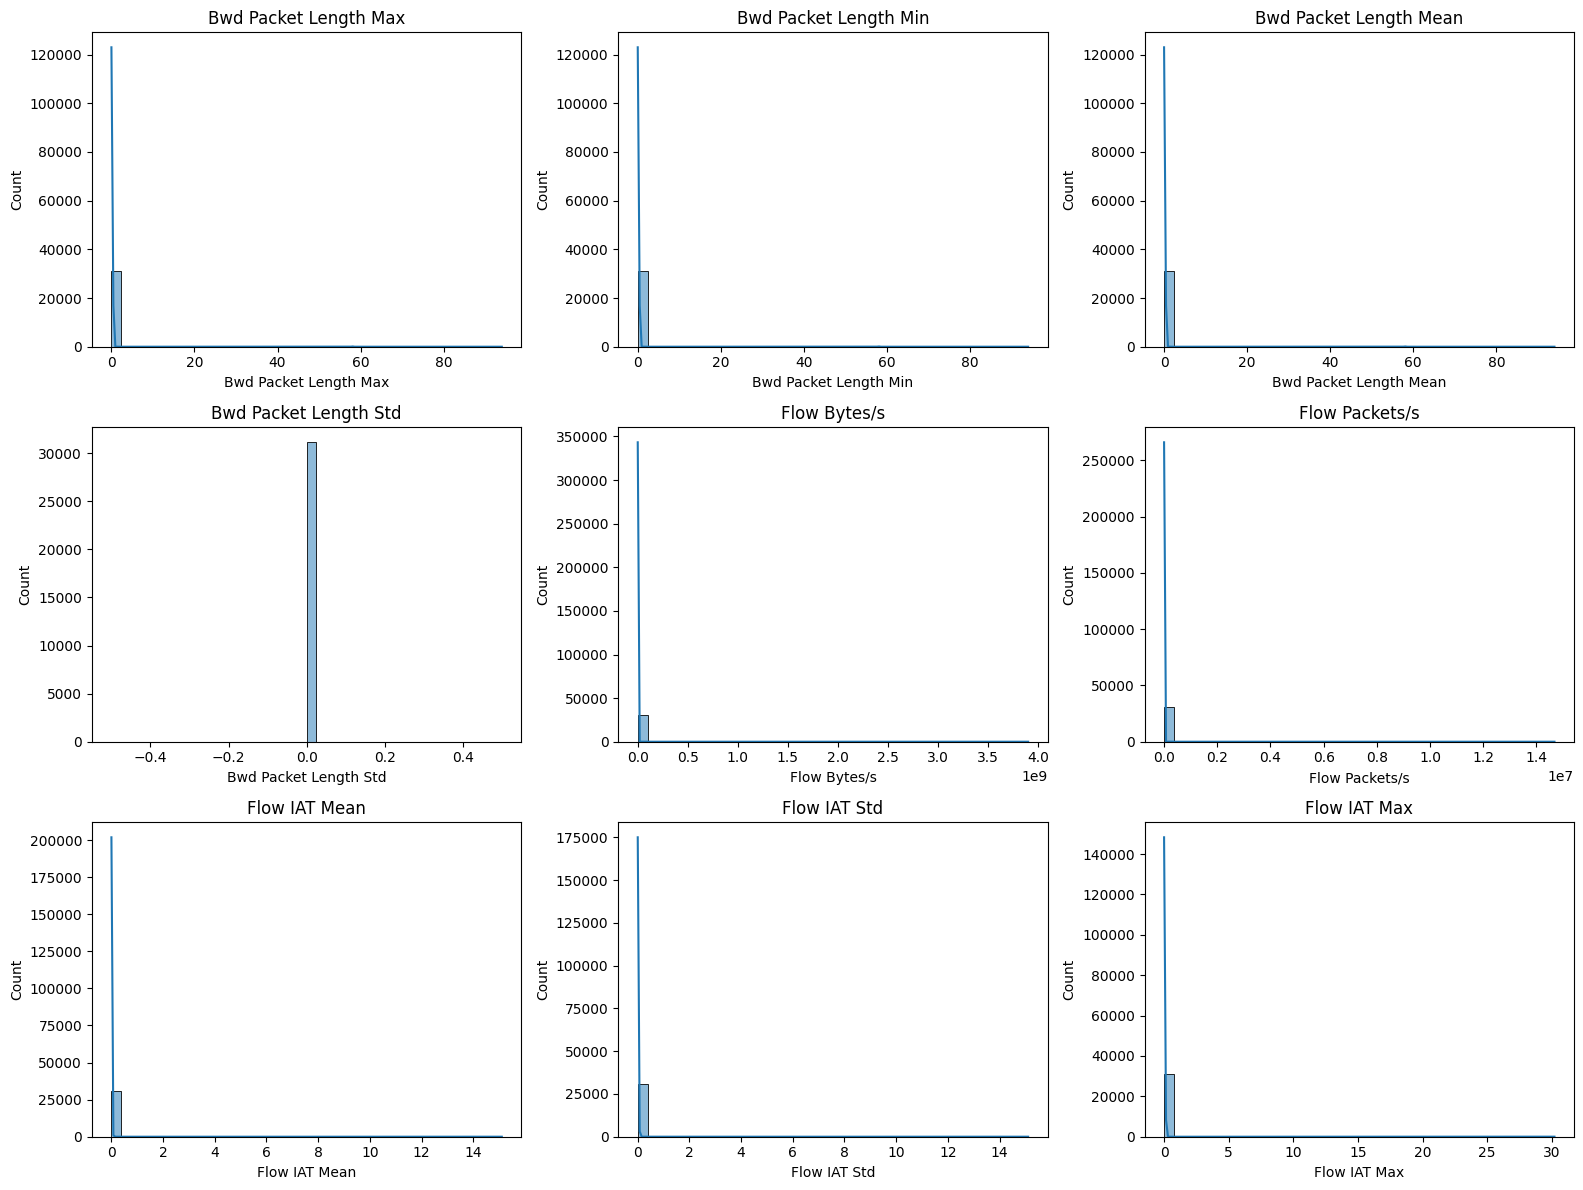

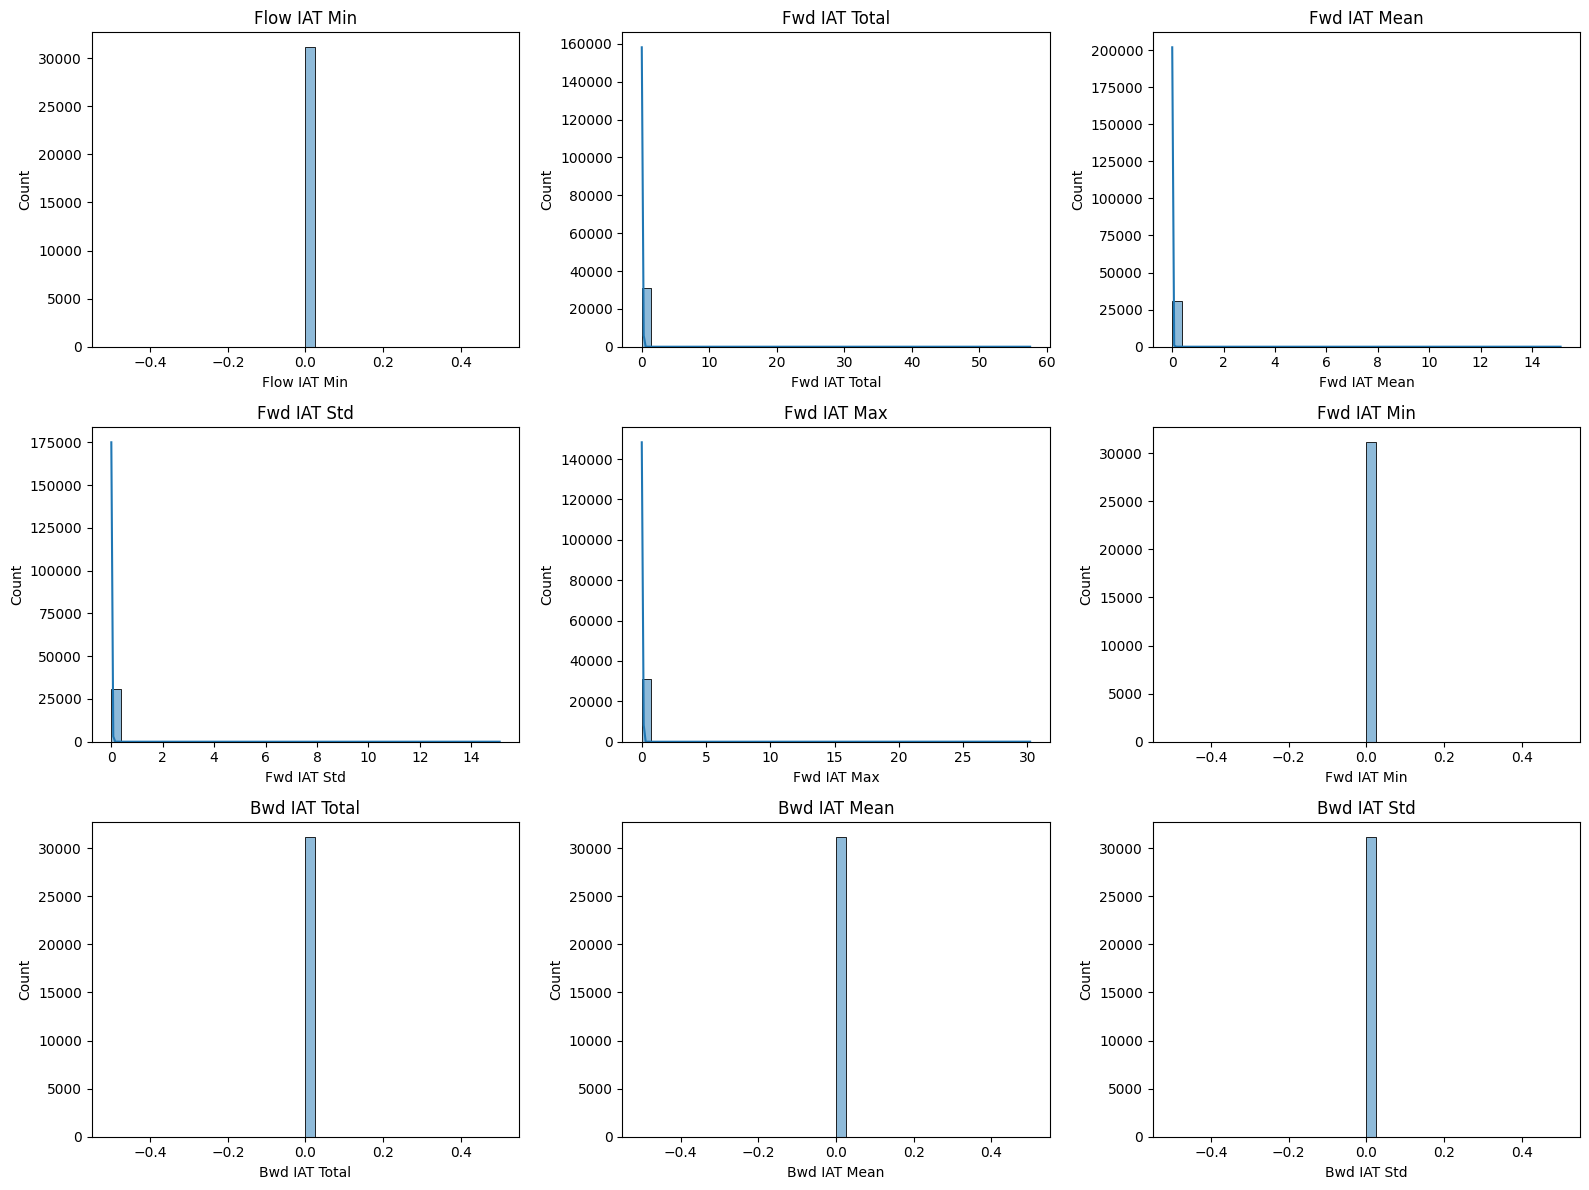

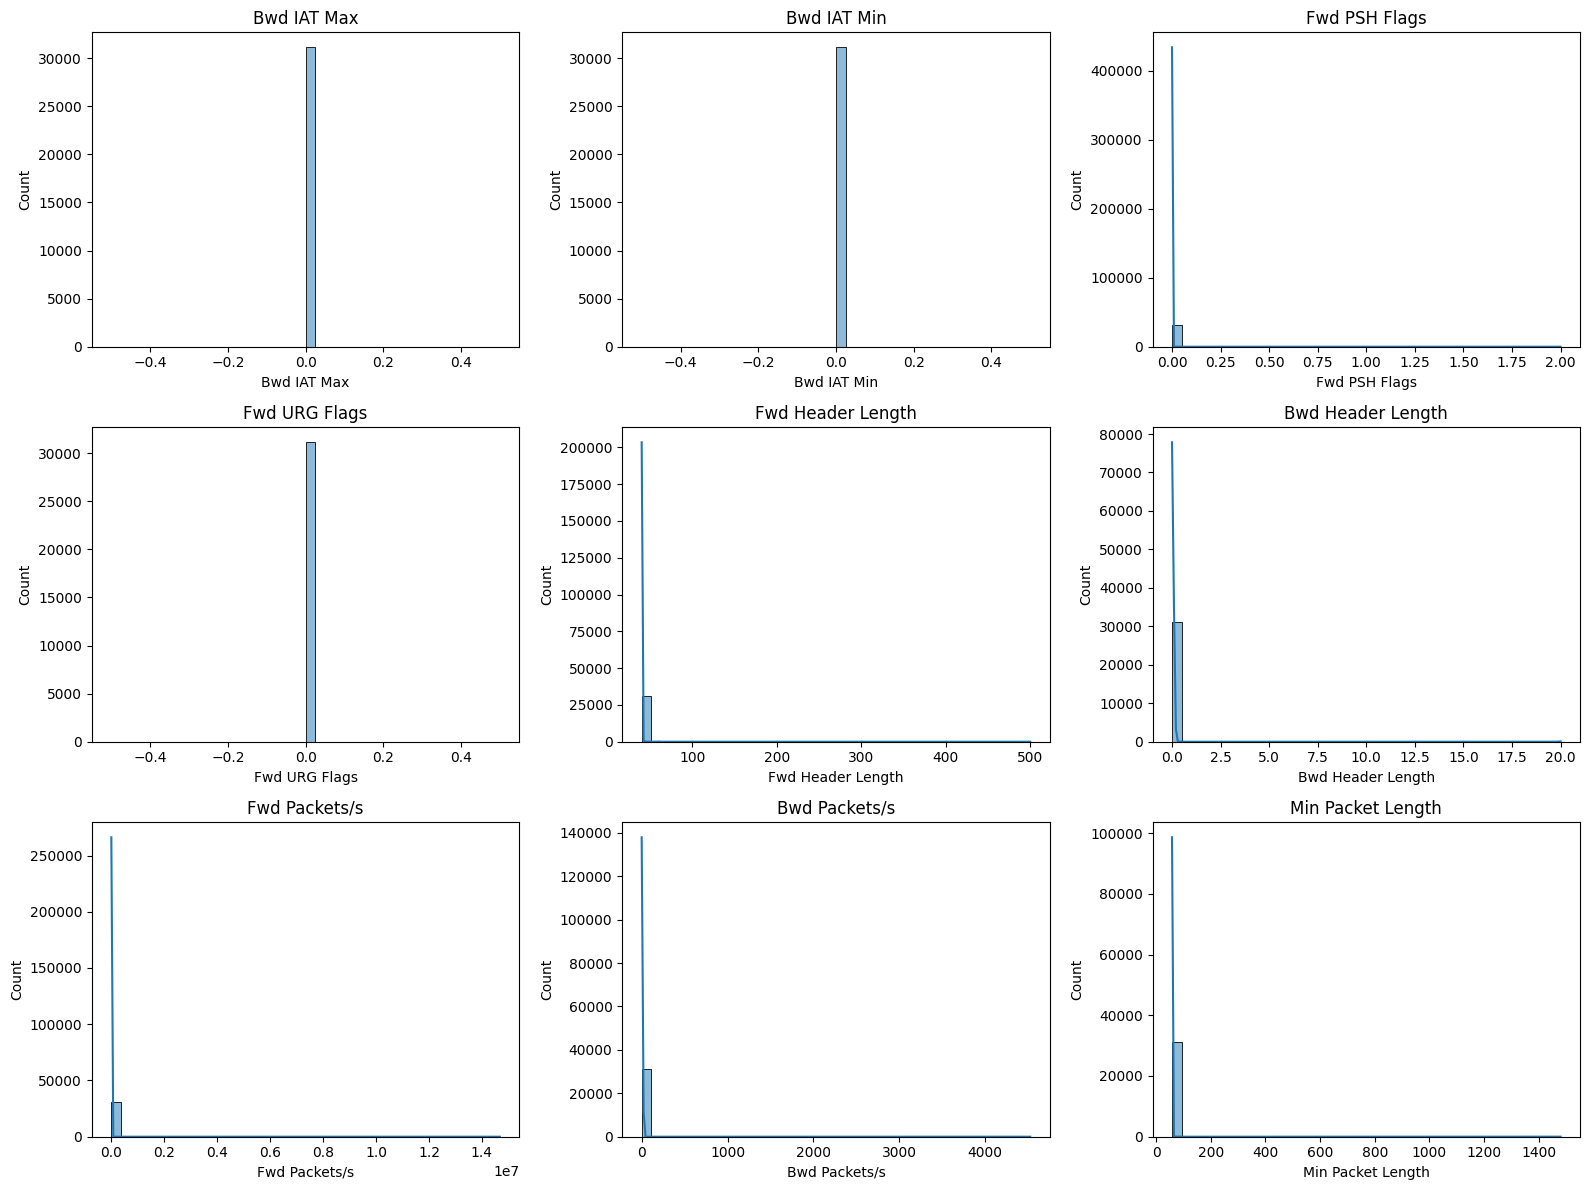

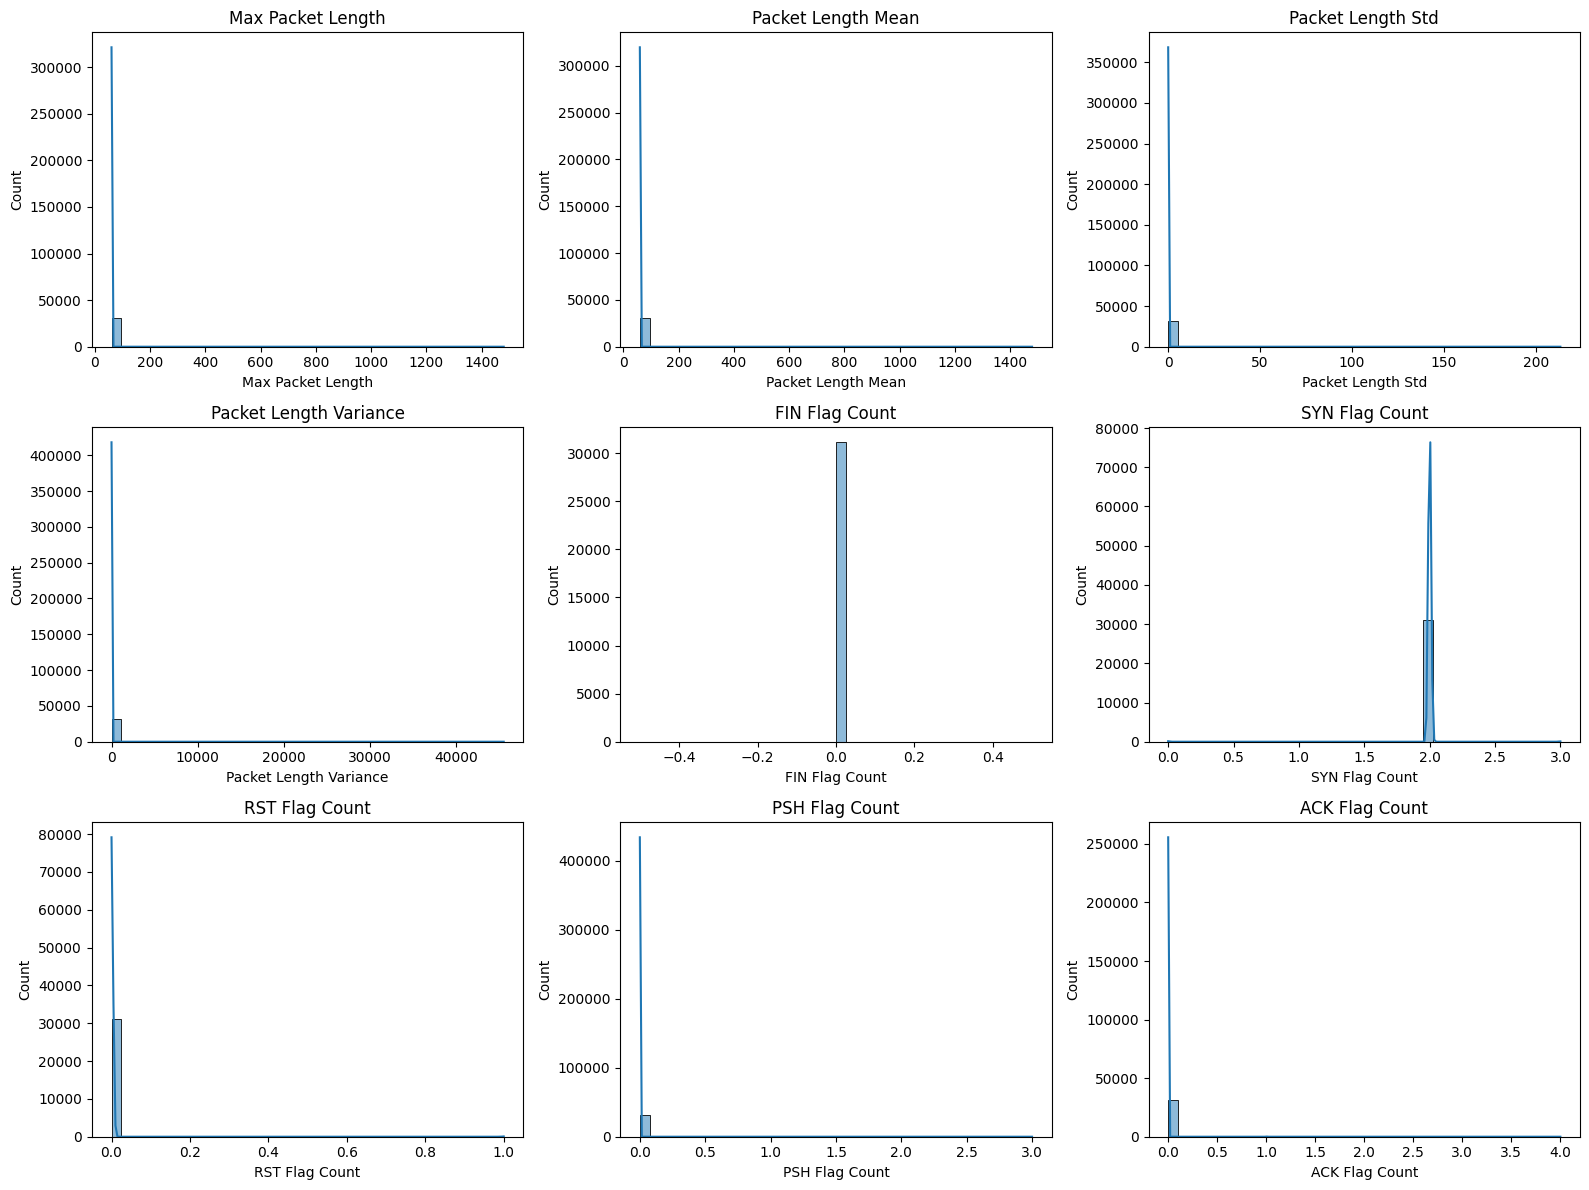

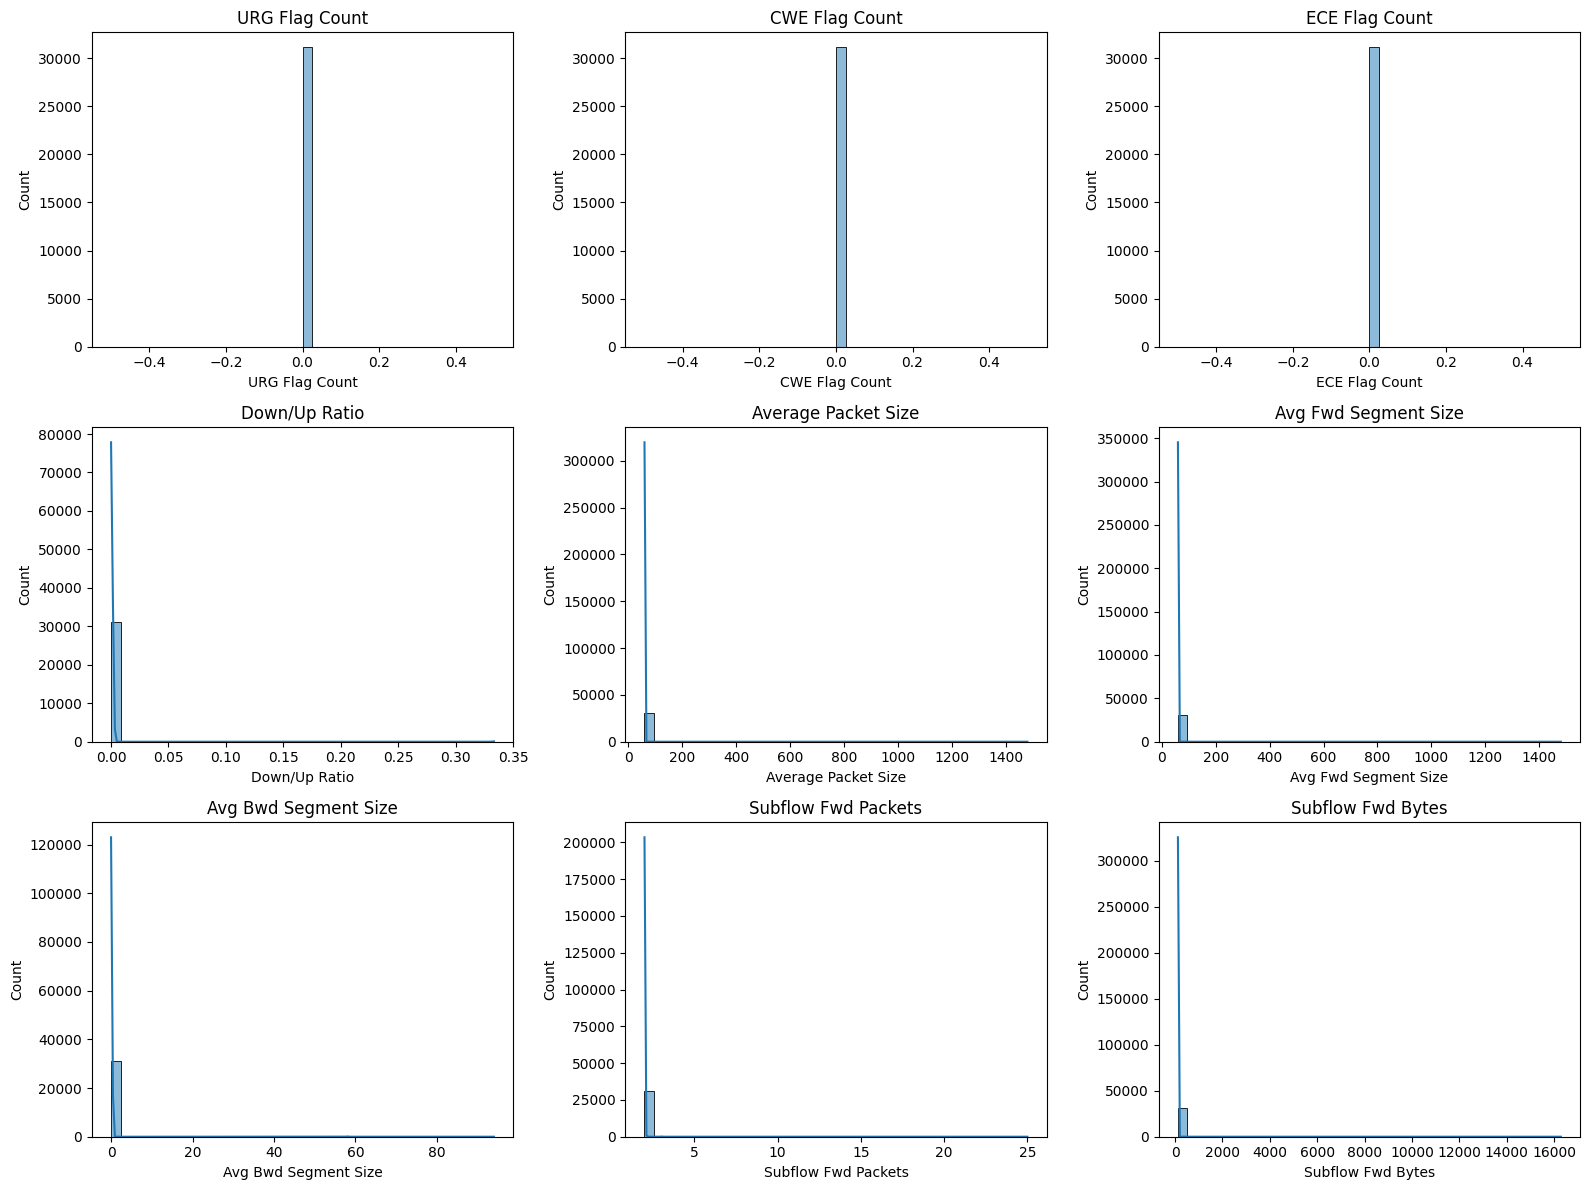

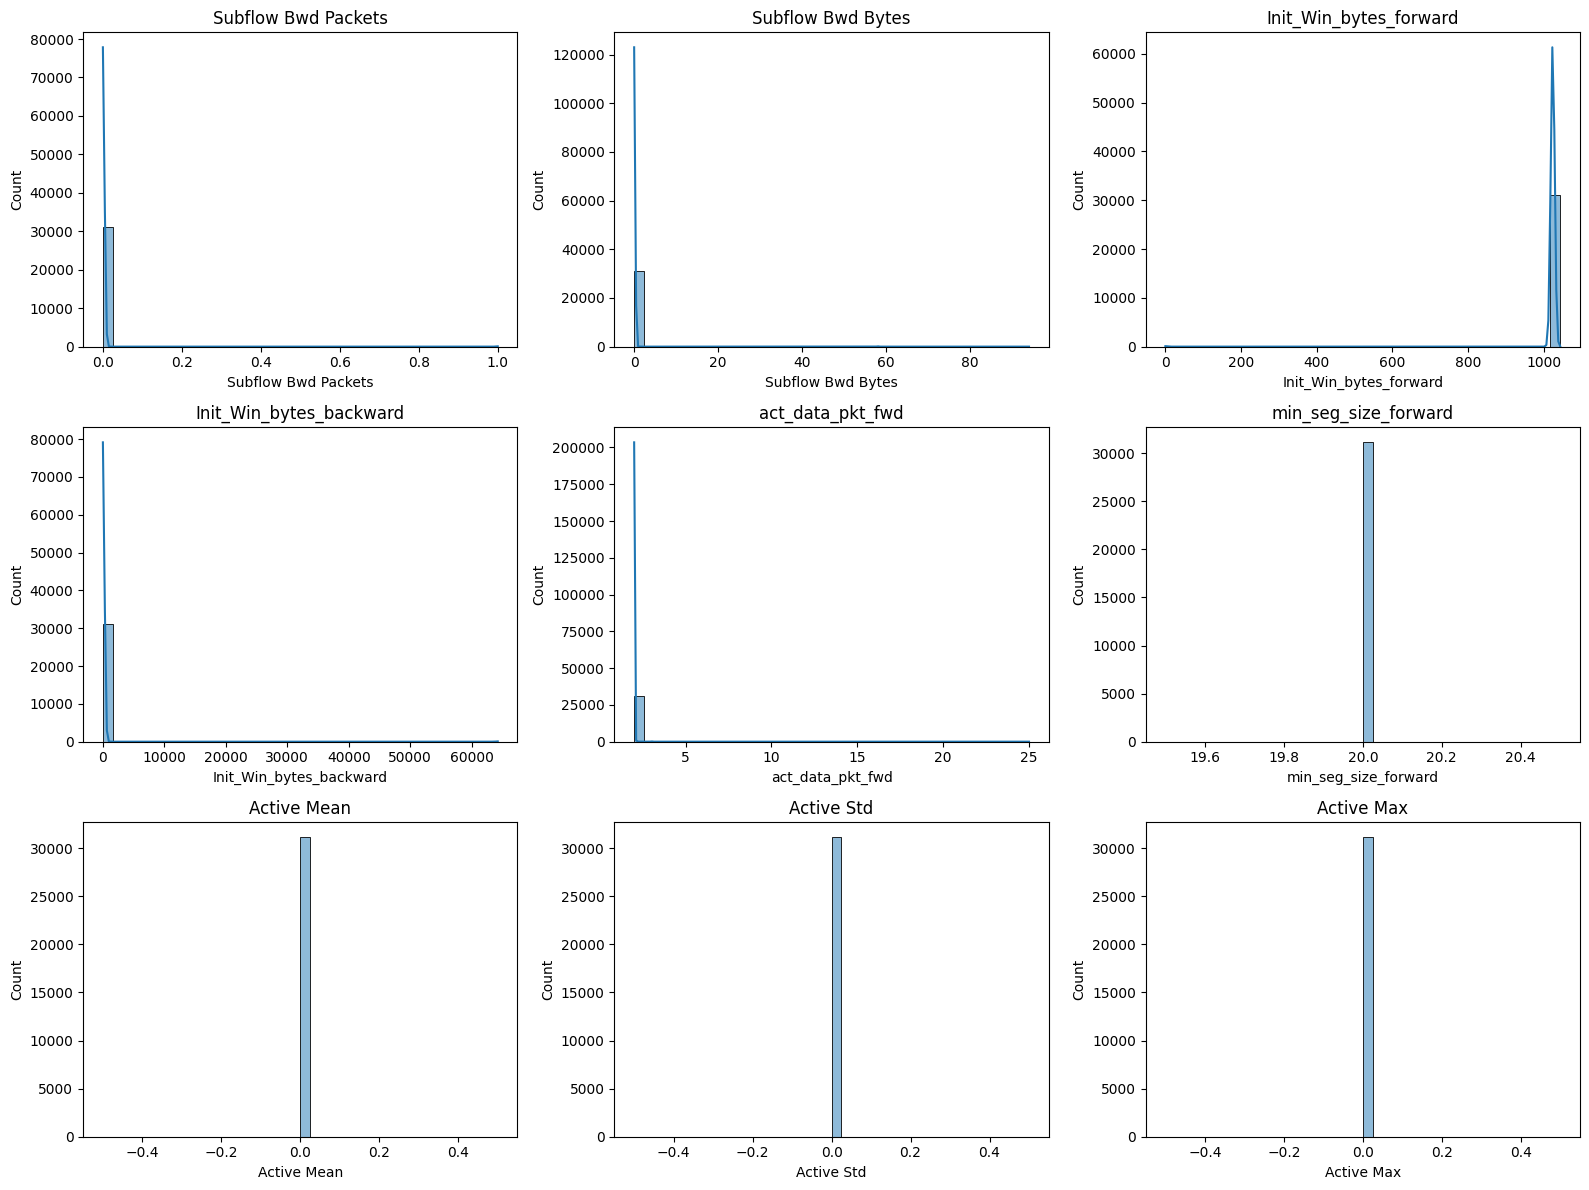

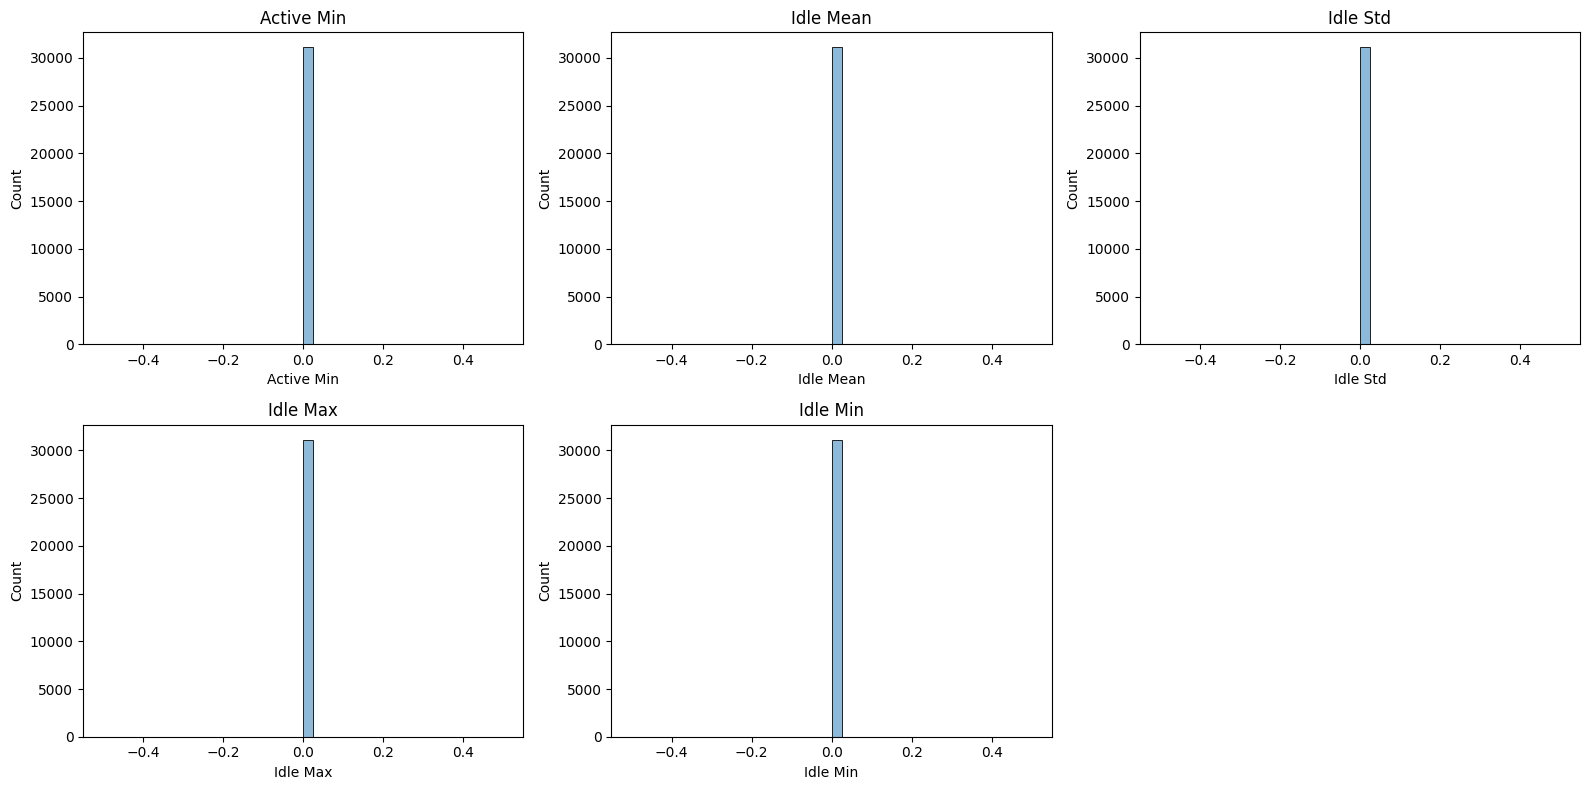

In [17]:
# Distribuição das colunas numéricas do DataFrame df
numeric_cols = df.select_dtypes(include="number").columns.tolist()

print(f"Total de colunas numéricas: {len(numeric_cols)}")
display(df[numeric_cols].describe().T)

# Plota histogramas em lotes para não ficar poluído
cols_por_figura = 9
n_cols = 3

for i in range(0, len(numeric_cols), cols_por_figura):
    lote = numeric_cols[i:i + cols_por_figura]
    n_rows = (len(lote) + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
    axes = axes.flatten() if hasattr(axes, "flatten") else [axes]

    for ax, col in zip(axes, lote):
        sns.histplot(df[col], bins=40, kde=True, ax=ax)
        ax.set_title(col)

    # Remove eixos vazios
    for ax in axes[len(lote):]:
        ax.remove()

    plt.tight_layout()
    plt.show()

In [18]:
# Colunas sem variância (todos os valores iguais) no df_pred
colunas_sem_variancia = [c for c in df_pred.columns if df_pred[c].nunique(dropna=False) <= 1]

print(f"Total de colunas sem variância: {len(colunas_sem_variancia)}")

if colunas_sem_variancia:
    resumo_sem_variancia = pd.DataFrame({
        "coluna": colunas_sem_variancia,
        "valor_unico": [df_pred[c].iloc[0] for c in colunas_sem_variancia]
    })
    display(resumo_sem_variancia.sort_values("coluna").reset_index(drop=True))
else:
    print("Nenhuma coluna sem variância encontrada.")

Total de colunas sem variância: 22


,coluna,valor_unico
0,Active Max,0.0
1,Active Mean,0.0
2,Active Min,0.0
3,Active Std,0.0
4,Bwd IAT Max,0.0
5,Bwd IAT Mean,0.0
6,Bwd IAT Min,0.0
7,Bwd IAT Std,0.0
8,Bwd IAT Total,0.0
9,Bwd Packet Length Std,0.0


In [19]:
# Médias de todas as colunas numéricas do df_pred
medias_colunas = df_pred.mean(numeric_only=True).to_frame(name="media")
display(medias_colunas)

,media
Flow Duration,0.020538
Total Fwd Packets,2.007711
Total Backward Packets,0.000996
Total Length of Fwd Packets,122.262618
Total Length of Bwd Packets,0.058924
...,...
Active Min,0.000000
Idle Mean,0.000000
Idle Std,0.000000
Idle Max,0.000000


In [21]:
df_pred

,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,Bwd Packet Length Max,...,act_data_pkt_fwd,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min
0,25.702085,11,0,1100,0,100,100,100.00,0.000000,0,...,11,20,0,0,0,0,0,0,0,0
1,42.392740,25,0,5632,0,604,87,225.28,213.410313,0,...,25,20,0,0,0,0,0,0,0,0
2,57.548532,18,0,3870,0,215,215,215.00,0.000000,0,...,18,20,0,0,0,0,0,0,0,0
3,0.436694,5,0,325,0,65,65,65.00,0.000000,0,...,5,20,0,0,0,0,0,0,0,0
4,51.405335,16,0,3440,0,215,215,215.00,0.000000,0,...,16,20,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
31120,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0
31121,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0
31122,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0
31123,0.000000,2,0,120,0,60,60,60.00,0.000000,0,...,2,20,0,0,0,0,0,0,0,0


In [23]:
df_pred.columns

Index(['Flow Duration', 'Total Fwd Packets', 'Total Backward Packets',
       'Total Length of Fwd Packets', 'Total Length of Bwd Packets',
       'Fwd Packet Length Max', 'Fwd Packet Length Min',
       'Fwd Packet Length Mean', 'Fwd Packet Length Std',
       'Bwd Packet Length Max', 'Bwd Packet Length Min',
       'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow Bytes/s',
       'Flow Packets/s', 'Flow IAT Mean', 'Flow IAT Std', 'Flow IAT Max',
       'Flow IAT Min', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std',
       'Fwd IAT Max', 'Fwd IAT Min', 'Bwd IAT Total', 'Bwd IAT Mean',
       'Bwd IAT Std', 'Bwd IAT Max', 'Bwd IAT Min', 'Fwd PSH Flags',
       'Fwd URG Flags', 'Fwd Header Length', 'Bwd Header Length',
       'Fwd Packets/s', 'Bwd Packets/s', 'Min Packet Length',
       'Max Packet Length', 'Packet Length Mean', 'Packet Length Std',
       'Packet Length Variance', 'FIN Flag Count', 'SYN Flag Count',
       'RST Flag Count', 'PSH Flag Count', 'ACK Flag Count', '

In [24]:
# Gera um CSV com as médias das colunas numéricas de df_pred
output_csv = "data/processed/medias_colunas_df_pred.csv"

medias_para_csv = (
    medias_colunas.reset_index().rename(columns={"index": "coluna"})
    if "medias_colunas" in globals()
    else df_pred.mean(numeric_only=True).rename("media").reset_index().rename(columns={"index": "coluna"})
)

medias_para_csv.to_csv(output_csv, index=False)
print(f"CSV salvo em: {output_csv}")
medias_para_csv.head()

CSV salvo em: data/processed/medias_colunas_df_pred.csv


,coluna,media
0,Flow Duration,0.020538
1,Total Fwd Packets,2.007711
2,Total Backward Packets,0.000996
3,Total Length of Fwd Packets,122.262618
4,Total Length of Bwd Packets,0.058924
